[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ichristov/viscoelastic-startup/blob/main/notebooks/christov_christov_2010_second_grade.ipynb)

# LEARNING OBJECTIVE

After exploring this notebook, you will be able to regenerate, from scratch, the corrected solution of Stokes' first problem for a second-grade fluid given by [I. C. Christov & C. I. Christov (2010)](https://arxiv.org/abs/1003.2188), and the erroneous solution it corrects. Furthermore, you will be able to verify the correction against a numerical inversion of the Laplace transform, Puri's integral and the finite-difference scheme of that paper, reproduce its Fig. 1, and show which two other problems the erroneous solution actually solves.

Although the error corrected here is elementary, it is the one repeated, in one form or another, in every notebook of this repository: an impulsively started plate contributes $V_0\delta(t)$, and dropping it gives a solution that does not even satisfy the boundary condition and, in fact, describes a plate ramped on the retardation time $\alpha/\nu$.

# PRELIMINARIES

This notebook uses [NumPy](https://numpy.org) ([Harris _et al._, 2020](https://doi.org/10.1038/s41586-020-2649-2)), [SciPy](https://scipy.org) ([Virtanen _et al._, 2020](https://doi.org/10.1038/s41592-019-0686-2)), [SymPy](https://www.sympy.org) ([Meurer _et al._, 2017](https://doi.org/10.7717/peerj-cs.103)), [Matplotlib](https://matplotlib.org) ([Hunter, 2007](https://doi.org/10.1109/MCSE.2007.55)) and [mpmath](https://mpmath.org) ([mpmath development team, 2023](https://mpmath.org/)).

[run the next cell to setup Python environment customizations and load packages]

In [1]:
# interactive plots setup
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

# sympy setup
import sympy as sp
sp.init_printing()
from sympy.vector import *

# plotting customizations
from matplotlib import colormaps, animation, rc
from matplotlib import pyplot as plt
size=16
params = {'legend.fontsize': 'large',
#          'figure.figsize': (20,8),
          'axes.labelsize': size,
          'axes.titlesize': size,
          'xtick.labelsize': size*0.875,
          'ytick.labelsize': size*0.875,
          'axes.titlepad': 25}
plt.rcParams.update(params)
%matplotlib inline

# for animations
from IPython.display import HTML

# numerics
import numpy as np
from scipy.integrate import quad
from scipy.special import erfc
from scipy.linalg import solve_banded
import mpmath as mp
import os

# for Colab only: to save plots as files and download them
#from google.colab import files

## Credit

Initial version of this notebook written by [Ivan C. Christov](http://christov.tmnt-lab.org), Purdue University.

Reproducing results of I. C. Christov and C. I. Christov.

# THE PROBLEM

The initial-boundary-value problem (IBVP), Eq. (1) of I. C. Christov & C. I. Christov (2010), for the velocity $v(y,t)$ of a second-grade fluid above a plate suddenly moved with velocity $V_0$:
\begin{align*}
    \left(\nu + \alpha\frac{\partial}{\partial t}\right)\frac{\partial^2 v}{\partial y^2} &= \frac{\partial v}{\partial t}, & (y,t)\in(0,\infty)\times(0,\infty),\\
    v(0,t) &= V_0\theta(t),\qquad v(y,t),\; \frac{\partial v}{\partial y}(y,t) \to 0 \;\;\text{as}\;\; y\to\infty, & t>0,\\
    v(y,0) &= 0, & y>0,
\end{align*}
where $\theta(t)$ is the [Heaviside step function](https://en.wikipedia.org/wiki/Heaviside_step_function), $\nu$ is the kinematic viscosity and $\alpha$ is the first normal-stress modulus divided by the density. The paper keeps $\nu$ and $\alpha$ in consistent units with $V_0 = 1$; the solution depends on them only through the variables of its Eq. (6),
$$
    u=\frac{v}{V_0},\qquad Y=y,\qquad T =\nu t, \qquad l^2=\alpha.
$$
Fig. 1 of the paper uses $\nu = 0.1$ with $\alpha = 0.01$, $t = 0.01$ (left) and $\alpha = 0.1$, $t = 0.5$ (right).

Note that the plate velocity is _not_ an arbitrary function of time: for this IBVP to be Stokes' first problem, the plate must move _suddenly_ at $t = 0^+$, so its velocity must be of the form $V(t) = \tilde{V}(t)\theta(t)$, with $\tilde{V}(t)$ smooth. In the Fourier sine transform, $\int_0^\infty \frac{\partial^2 v}{\partial y^2}\sin(\xi y)\,\mathrm{d}y = -\xi^2\bar{v}_s + \xi\, V(t)$, so the mixed derivative brings in $\alpha\xi V^\prime(t)$, and the correct expression in lieu of $V^\prime(t)$ is $\tilde{V}^\prime(t)\theta(t) + \tilde{V}(t)\delta(t)$: here, $V_0\delta(t)$, _not_ zero. The Dirac delta has no point values, but as a forcing term in $t$ it contributes to the solution; Prof. Arthur Mattuck's MIT 18.03 lecture on [impulse inputs](https://ocw.mit.edu/courses/18-03-differential-equations-spring-2010/resources/lecture-23-use-with-impulse-inputs/) explains why. (Whenever $\tilde{V}(0) = 0$, the $\delta(t)$ term vanishes, and by pure luck the proper answer is obtained despite the erroneous derivation.)

# THE ERRONEOUS SOLUTION

> &#x26A0;&#xFE0F; **ERRONEOUS SOLUTION, reproduced as printed** in Eq. (2.6) of Fetec&#259;u & Zierep (2001) ([doi:10.1007/BF01178551](https://doi.org/10.1007/BF01178551)), p. 136. Their subsidiary equation, Eq. (2.3), takes $V^\prime(t) = 0$ for a plate moving with constant velocity $V$. It is shown below to be wrong.

$$
    v(y,t) = V\left[1 - \frac{2}{\pi}\int_0^\infty \frac{\sin(y\xi)}{\xi}\,\mathrm{e}^{-\frac{\nu\xi^2}{1+\alpha\xi^2}t}\,\mathrm{d}\xi\right].
$$

In [2]:
# WRONG, as printed: Eq. (2.6) of Fetecau & Zierep (2001)
def sine_integral(g, y, t, nu, alpha):
    """Integral of g(xi, t, nu, alpha)*sin(xi*y) over 0 < xi < infinity."""
    # ordinary quadrature on (0, 1), then a Fourier-weighted rule for the slowly decaying tail
    head = quad(lambda xi: g(xi, t, nu, alpha)*np.sin(xi*y), 0, 1, limit=200)[0]
    tail = quad(g, 1, np.inf, args=(t, nu, alpha), weight='sin', wvar=y, limlst=100)[0]
    return head + tail

def g_decay(xi, t, nu, alpha):
    """exp(-nu xi^2 t/(1 + alpha xi^2))/xi."""
    return np.exp(-nu*xi**2*t/(1 + alpha*xi**2))/xi

def wrong_fetecau_zierep_26(y, t, nu, alpha):
    """Erroneous solution, as printed: Eq. (2.6) of Fetecau & Zierep (2001), with V = 1."""
    if y == 0:
        return 1.0   # sin(0) = 0, so the formula gives the plate velocity exactly
    return 1 - 2/np.pi*sine_integral(g_decay, y, t, nu, alpha)

> &#x26A0;&#xFE0F; **END OF THE ERRONEOUS SOLUTION.** The cells below are correct.

# THE CORRECT SOLUTION

With $V^\prime(t) = V_0\delta(t)$, where $\delta(t)$ is the [Dirac delta](https://en.wikipedia.org/wiki/Dirac_delta_function), the Fourier sine transform in $y$ followed by the [Laplace transform](https://en.wikipedia.org/wiki/Laplace_transform) in $t$ gives Eq. (2) of I. C. Christov & C. I. Christov (2010),
$$
    \bar{v}_{s}(\xi,s) = V_0\left\{\frac{\nu \xi}{s[s(1+\alpha\xi^2)+\nu \xi^2]}+ \frac{\alpha\xi}{s(1+\alpha\xi^2)+\nu \xi^2}\right\},
$$
correcting the misprint in the published Eq. (2), whose prefactor is $2V_0$: with the transform convention $\bar{f}_s(\xi) = \int_0^\infty f(y)\sin(\xi y)\,\mathrm{d}y$ and its inverse $(2/\pi)\int_0^\infty \bar{f}_s(\xi)\sin(\xi y)\,\mathrm{d}\xi$, which gives Eq. (3), the prefactor is $V_0$.

The next cell derives the transform with SymPy, with and without the $V_0\delta(t)$ term; it should print the braces above times $V_0$, the wrong transform (the first quotient only), and the ratio of the published Eq. (2) to the derived one, which is 2.

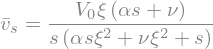

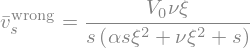

In [3]:
# Eq. (2) of I. C. Christov & C. I. Christov (2010) and Eq. (2.3) of Fetecau & Zierep (2001), in the Laplace domain
t = sp.Symbol('t', real=True)   # not positive=True, otherwise SymPy sets DiracDelta(t) = 0
s = sp.Symbol('s', positive=True)
xi, nu, alpha, V0 = sp.symbols('xi nu alpha V_0', positive=True)
w = sp.Function('w')   # Fourier sine transform of v
W, w0 = sp.symbols(r'\bar{v}_s w_0')

def laplace(expr):
    """Laplace transform in t, with W and w(0) as symbols."""
    L = sp.laplace_transform(expr, t, s, noconds=True)
    L = L.subs(sp.LaplaceTransform(w(t), t, s), W).subs(w(0), w0)
    return sp.expand(L)

# the Fourier sine transform of d^2v/dy^2 is -xi^2 w + xi v(0,t), with v(0,t) = V0 H(t)
plate = V0*sp.Heaviside(t)
viscous_correct = nu*(-xi**2*w(t) + xi*plate) + alpha*sp.diff(-xi**2*w(t) + xi*plate, t)
viscous_wrong = nu*(-xi**2*w(t) + xi*plate) + alpha*sp.diff(-xi**2*w(t), t)   # V'(t) taken as 0
W_correct = sp.solve(laplace(viscous_correct - w(t).diff(t)).subs(w0, 0), W)[0]
W_wrong = sp.solve(laplace(viscous_wrong - w(t).diff(t)).subs(w0, 0), W)[0]
eq2_published = 2*V0*(nu*xi/(s*(s*(1 + alpha*xi**2) + nu*xi**2)) + alpha*xi/(s*(1 + alpha*xi**2) + nu*xi**2))
display(sp.Eq(W, sp.factor(W_correct)))
display(sp.Eq(sp.Symbol(r'\bar{v}_s^\mathrm{wrong}'), sp.factor(W_wrong)))
display(sp.Eq(sp.Symbol(r'\mathrm{published\ Eq.\ (2)}/\bar{v}_s'), sp.simplify(eq2_published/W_correct)))

Inverting gives the correct solution, Eq. (3) of I. C. Christov & C. I. Christov (2010),
$$
    v(y,t) = V_0\theta(t)\left[1-\frac{2}{\pi}\int_{0}^{\infty}\frac{\sin(\xi y)}{\xi} \exp\left(\frac{-\nu \xi^2t}{1+\alpha\xi^2}\right)\,\mathrm{d}\xi+ \frac{2\alpha}{\pi}\int_{0}^{\infty}\frac{\xi \sin(\xi y)}{1+\alpha\xi^2}\exp\left(\frac{-\nu \xi^2 t}{1+\alpha\xi^2}\right)\,\mathrm{d}\xi\right].
$$
The second integral is missing from Eq. (2.6) of Fetec&#259;u & Zierep (2001). The paper evaluated the integrals with _Mathematica_'s `NIntegrate`; here [`scipy.integrate.quad`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.quad.html) is used.

In [4]:
# Eq. (3) of I. C. Christov & C. I. Christov (2010): correct solution
def g_second(xi, t, nu, alpha):
    """xi/(1 + alpha xi^2) exp(-nu xi^2 t/(1 + alpha xi^2)), the integrand of the second integral of Eq. (3)."""
    return xi/(1 + alpha*xi**2)*np.exp(-nu*xi**2*t/(1 + alpha*xi**2))

def unsteadyv(y, t, nu, alpha):
    """Correct solution, Eq. (3) of I. C. Christov & C. I. Christov (2010), with V0 = 1, at one point y > 0."""
    if y == 0:
        return 1.0   # sin(0) = 0, so the formula gives the plate velocity exactly
    if t <= 0:
        return 0.0
    return 1 - 2/np.pi*sine_integral(g_decay, y, t, nu, alpha) + 2*alpha/np.pi*sine_integral(g_second, y, t, nu, alpha)

def profile(func, y, t, nu, alpha):
    """Evaluate a point-wise solution func(y, t, nu, alpha) on an array of y > 0."""
    u = np.zeros_like(y)
    for j in range(len(y)):
        u[j] = func(y[j], t, nu, alpha)
    return u

Here, the second integral in Eq. (3), which represents the contribution of the second quotient in Eq. (2), and hence of $V_0\delta(t)$, is precisely the start-up jump: at $t = 0^+$ the first integral vanishes for $y > 0$, while the second equals $V_0\mathrm{e}^{-y/\sqrt{\alpha}}$. The fluid near the plate is set in motion _instantaneously_, because the mixed-derivative term responds at once to the jump of the plate velocity. Lacking this integral, Eq. (2.6) of Fetec&#259;u & Zierep (2001) has no start-up jump at all.

# AN INDEPENDENT CHECK

Three independent checks. First, using only the Laplace transform in $t$ ([Puri, 1984](https://doi.org/10.1007/BF01329198)), the solution of the IBVP in the Laplace domain is
$$
    \bar{v}(y,s) = \frac{V_0}{s}\exp\left(-y\sqrt{\frac{s}{\nu+\alpha s}}\right),
$$
inverted numerically by the algorithm of [de Hoog _et al._ (1982)](https://doi.org/10.1137/0903022) in [mpmath's `invertlaplace`](https://mpmath.org/doc/current/calculus/inverselaplace.html). Second, Eq. (3) rewritten with the variables of Eq. (6) and $\eta=\xi^2/(1+l^2\xi^2)$ is Eq. (7) of I. C. Christov & C. I. Christov (2010), Puri's form:
$$
    u(Y,T)=\theta(T)\left[1-\frac{1}{\pi}\int_{0}^{l^{-2}}\mathrm{e}^{-\eta T} \sin\left( \frac{Y}{l}\sqrt{\frac{\eta}{l^{-2}-\eta}}\,\right)\frac{\mathrm{d}\eta}{\eta}\right].
$$
The next cell checks with SymPy that $\bar{v}$ solves the Laplace transform of the IBVP, $s\bar{v} = (\nu + \alpha s)\,\frac{\partial^2 \bar{v}}{\partial y^2}$ with $\bar{v}(0,s) = V_0/s$; it should print two zeros.

In [5]:
# Laplace-domain solution of Eq. (1) of I. C. Christov & C. I. Christov (2010)
y = sp.Symbol('y', positive=True)
vbar_sym = V0/s*sp.exp(-y*sp.sqrt(s/(nu + alpha*s)))
(sp.simplify(s*vbar_sym - (nu + alpha*s)*vbar_sym.diff(y, 2)), sp.simplify(vbar_sym.subs(y, 0) - V0/s))

In [6]:
# Laplace-domain solution inverted by de Hoog's algorithm; Eq. (7) of I. C. Christov & C. I. Christov (2010)
def vbar_mp(s, y, nu, alpha):
    """Laplace-domain solution of Eq. (1), with V0 = 1, in mpmath arithmetic."""
    return mp.exp(-y*mp.sqrt(s/(nu + alpha*s)))/s

def dehoog_inverse(y, t, nu, alpha):
    """Laplace-domain solution inverted by mpmath's de Hoog algorithm, point by point in y."""
    u = np.zeros_like(y)
    for j in range(len(y)):
        u[j] = float(mp.invertlaplace(lambda s: vbar_mp(s, y[j], nu, alpha), t, method='dehoog'))
    return u

def puri_7(y, t, nu, alpha):
    """Eq. (7) of I. C. Christov & C. I. Christov (2010) with Y = y, T = nu t, l^2 = alpha, at one point y > 0."""
    l = np.sqrt(alpha)
    T = nu*t
    integral = quad(lambda eta: np.exp(-eta*T)*np.sin(y/l*np.sqrt(eta/(1/l**2 - eta)))/eta, 0, 1/l**2, limit=2000)[0]
    return 1 - integral/np.pi

Third, the finite-difference scheme of Eq. (4) of I. C. Christov & C. I. Christov (2010),
$$
    \delta_{t+}\mathfrak{v}^{n}_j - \alpha \delta_{t+}\delta_{y+}\delta_{y-}\mathfrak{v}^{n}_j = \nu  \frac{1}{2}\left(\delta_{y+}\delta_{y-}\mathfrak{v}^{n+1}_j + \delta_{y+}\delta_{y-}\mathfrak{v}^{n}_j\right),
$$
on $y_j = j\Delta y$, $t^n = n\Delta t$, with $\Delta y = L/(M-1)$, $\Delta t = t_f/(K-1)$, and the boundary conditions of Eq. (5),
$$
    \mathfrak{v}_0^n = \begin{cases}0, &n=0,\\ V_0, &1\le n\le K-1, \end{cases}\qquad \mathfrak{v}_{M-1}^n = 0,\quad 0\le n\le K-1.
$$
Keeping $\mathfrak{v}_0^0 = 0$ matters: the jump of the plate velocity between the first two time levels is what the mixed term $\alpha\delta_{t+}\delta_{y+}\delta_{y-}$ sees as $V_0\delta(t)$. The paper used $M=5000$, $K=1000$, $L=20$.

In [7]:
# Eqs. (4)-(5) of I. C. Christov & C. I. Christov (2010): finite-difference scheme
def sg_fd(nu, alpha, tf, L=20.0, M=5000, K=1000, ramp_time=0.0, v00=0.0, oscillation='', omega=0.0, gamma=0.0):
    """Scheme of Eq. (4) with the boundary conditions of Eq. (5) of I. C. Christov & C. I. Christov (2010), V0 = 1."""
    # ramp_time > 0 moves the plate with 1 - exp(-t/ramp_time) instead of 1; oscillation = 'cos' or 'sin'
    # moves it with cos(omega t) or sin(omega t); v00 is the plate velocity at n = 0;
    # gamma > 0 adds the porous-medium term, d^2/dy^2 -> d^2/dy^2 - gamma^2
    dy = L/(M - 1)
    dt = tf/(K - 1)
    y = np.linspace(0, L, M)
    v = np.zeros(M)
    v[0] = v00
    a = alpha/dy**2
    b = nu*dt/(2*dy**2)
    # tridiagonal matrix of (1 - (alpha + nu dt/2) delta^2/dy^2) acting on the interior points
    ab = np.zeros((3, M-2))
    ab[0, 1:] = -(a + b)
    ab[1, :] = 1 + 2*(a + b) + (alpha + nu*dt/2)*gamma**2
    ab[2, :-1] = -(a + b)
    for n in range(1, K):
        if ramp_time > 0:
            plate = 1 - np.exp(-n*dt/ramp_time)
        elif oscillation == 'cos':
            plate = np.cos(omega*n*dt)
        elif oscillation == 'sin':
            plate = np.sin(omega*n*dt)
        else:
            plate = 1.0
        rhs = v[1:-1] - (a - b)*(v[2:] - 2*v[1:-1] + v[:-2]) + (alpha - nu*dt/2)*gamma**2*v[1:-1]
        rhs[0] = rhs[0] + (a + b)*plate
        v_new = np.zeros(M)
        v_new[0] = plate
        v_new[1:-1] = solve_banded((1, 1), ab, rhs)
        v = v_new
    return y, v

The next cell prints the checks:

* the limit $\alpha = 0$ (Newtonian fluid), where Eqs. (3) and (2.6) both reduce to $\mathrm{erfc}[y/(2\sqrt{\nu t})]$ (should be at the quadrature tolerance);
* for both panels of Fig. 1: Eq. (3) against de Hoog's inversion (about $10^{-10}$), Puri's Eq. (7) and the scheme of Eqs. (4)&ndash;(5) on the paper's grid; the size of the error of Eq. (2.6); and the value of Eq. (2.6) at the wall, which should be $1-\mathrm{e}^{-\nu t/\alpha}$ instead of 1;
* the convergence of the scheme as $M$ and $K$ are doubled together (formally $O[(\Delta t)^2 + (\Delta y)^2]$, but first order in practice, because of the start-up jump).

In [8]:
# Checks for I. C. Christov & C. I. Christov (2010)
print('LIMIT alpha = 0 (should be at the quadrature tolerance)')
y_limit = np.array([0.05, 0.1, 0.2])
nu, t = 0.1, 0.3
exact_newtonian = erfc(y_limit/(2*np.sqrt(nu*t)))
print(f'  max|Eq. (3) - erfc| = {np.abs(profile(unsteadyv, y_limit, t, nu, 0.0) - exact_newtonian).max():.1e}, '
      f'max|Eq. (2.6) - erfc| = {np.abs(profile(wrong_fetecau_zierep_26, y_limit, t, nu, 0.0) - exact_newtonian).max():.1e}')

panels = [(0.1, 0.01, 0.01, 0.5), (0.1, 0.1, 0.5, 1.5)]   # nu, alpha, t, ymax of Fig. 1
for nu, alpha, t, ymax in panels:
    print(f'\nnu = {nu}, alpha = {alpha}, t = {t}, max over 0.02 <= y <= {ymax}')
    y = np.linspace(0.02, ymax, 25)
    u_correct = profile(unsteadyv, y, t, nu, alpha)
    u_dehoog = dehoog_inverse(y, t, nu, alpha)
    y_fd, v_fd = sg_fd(nu, alpha, t)
    print(f'  Eq. (3) vs de Hoog: {np.abs(u_correct - u_dehoog).max():.1e}')
    assert np.abs(u_correct - u_dehoog).max() < 1e-6   # a regression guard: the notebook stops here if a future edit breaks the agreement
    print(f'  Eq. (3) vs Puri, Eq. (7): {np.abs(u_correct - profile(puri_7, y, t, nu, alpha)).max():.1e}')
    print(f'  Eq. (3) vs scheme, M = 5000, K = 1000: {np.abs(u_correct - np.interp(y, y_fd, v_fd)).max():.1e}')
    print(f'  wrong Eq. (2.6) - Eq. (3): {np.abs(profile(wrong_fetecau_zierep_26, y, t, nu, alpha) - u_correct).max():.2f}')
    print(f'  at y = 1e-5: Eq. (2.6) = {wrong_fetecau_zierep_26(1e-5, t, nu, alpha):.5f}, '
          f'1 - exp(-nu t/alpha) = {1 - np.exp(-nu*t/alpha):.5f}, Eq. (3) = {unsteadyv(1e-5, t, nu, alpha):.5f}')
    print('  convergence of the scheme versus de Hoog (observed order):')
    previous = None
    for M, K in [(1250, 250), (2500, 500), (5000, 1000), (10000, 2000)]:
        y_fd, v_fd = sg_fd(nu, alpha, t, M=M, K=K)
        error = np.abs(np.interp(y, y_fd, v_fd) - u_dehoog).max()
        if previous is None:
            print(f'    M = {M:5d}, K = {K:4d}: {error:.1e}')
        else:
            print(f'    M = {M:5d}, K = {K:4d}: {error:.1e} ({np.log2(previous/error):.2f})')
        previous = error

LIMIT alpha = 0 (should be at the quadrature tolerance)
  max|Eq. (3) - erfc| = 1.1e-16, max|Eq. (2.6) - erfc| = 1.1e-16

nu = 0.1, alpha = 0.01, t = 0.01, max over 0.02 <= y <= 0.5


  Eq. (3) vs de Hoog: 2.5e-11


  Eq. (3) vs Puri, Eq. (7): 6.8e-08
  Eq. (3) vs scheme, M = 5000, K = 1000: 1.5e-05
  wrong Eq. (2.6) - Eq. (3): 0.75
  at y = 1e-5: Eq. (2.6) = 0.09516, 1 - exp(-nu t/alpha) = 0.09516, Eq. (3) = 0.99991
  convergence of the scheme versus de Hoog (observed order):
    M =  1250, K =  250: 2.2e-03
    M =  2500, K =  500: 6.3e-04 (1.81)
    M =  5000, K = 1000: 1.5e-05 (5.41)


    M = 10000, K = 2000: 1.5e-06 (3.28)

nu = 0.1, alpha = 0.1, t = 0.5, max over 0.02 <= y <= 1.5


  Eq. (3) vs de Hoog: 3.8e-11


  Eq. (3) vs Puri, Eq. (7): 1.0e-08
  Eq. (3) vs scheme, M = 5000, K = 1000: 3.3e-05
  wrong Eq. (2.6) - Eq. (3): 0.58
  at y = 1e-5: Eq. (2.6) = 0.39347, 1 - exp(-nu t/alpha) = 0.39347, Eq. (3) = 0.99999
  convergence of the scheme versus de Hoog (observed order):
    M =  1250, K =  250: 1.2e-04
    M =  2500, K =  500: 6.4e-05 (0.90)
    M =  5000, K = 1000: 3.3e-05 (0.95)


    M = 10000, K = 2000: 1.8e-05 (0.92)


# THE PAPER'S FIGURE

This is Fig. 1 of I. C. Christov & C. I. Christov (2010): $v$ versus $y$ for (left) $\nu = 0.1$, $\alpha = 0.01$, $t=0.01$ and (right) $\nu = 0.1$, $\alpha = 0.1$, $t = 0.5$, with the incorrect solution dashed, the correct solution solid and the numerical solution dotted. (Correcting the misprint in the caption of the published figure, which labels the dashed curve Eq. (2.7) of Fetec&#259;u & Zierep (2001): it is their Eq. (2.6), as the text of the paper says; their Eq. (2.7) is the Newtonian case.)

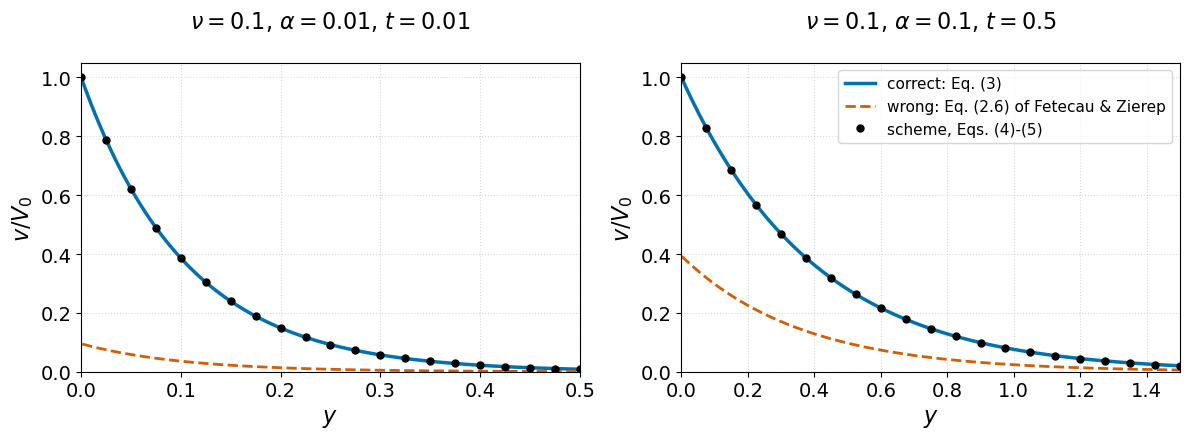

In [9]:
# Fig. 1 of I. C. Christov & C. I. Christov (2010)
panels = [(0.1, 0.01, 0.01, 0.5), (0.1, 0.1, 0.5, 1.5)]   # nu, alpha, t, ymax
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), tight_layout=True)
for k in range(2):
    nu, alpha, t, ymax = panels[k]
    ax = axes[k]
    y = np.linspace(1e-3, ymax, 120)
    y_fd, v_fd = sg_fd(nu, alpha, t)
    y_dots = np.linspace(0, ymax, 21)
    ax.plot(y, profile(unsteadyv, y, t, nu, alpha), color='#0072B2', linewidth=2.5, label='correct: Eq. (3)')
    ax.plot(y, profile(wrong_fetecau_zierep_26, y, t, nu, alpha), color='#D55E00', linewidth=2, linestyle='dashed',
            label='wrong: Eq. (2.6) of Fetecau & Zierep')
    ax.plot(y_dots, np.interp(y_dots, y_fd, v_fd), 'o', color='black', markersize=5, label='scheme, Eqs. (4)-(5)')
    ax.set_xlabel('$y$')
    ax.set_ylabel('$v/V_0$')
    ax.set_xlim(0, ymax)
    ax.set_ylim(0, 1.05)
    ax.set_title(rf'$\nu = {nu}$, $\alpha = {alpha}$, $t = {t}$')
    ax.grid(alpha=0.5, linestyle='dotted')
axes[1].legend(loc='upper right', fontsize=11)
os.makedirs('../figures', exist_ok=True)
fig.savefig('../figures/christov_christov_2010_fig1.png', dpi=200, bbox_inches='tight')

It is curious to note _how_ Eq. (2.6) fails. For a second-grade fluid, the exponent $-\nu\xi^2 t/(1+\alpha\xi^2)$ tends to $-\nu t/\alpha$ as $\xi\to\infty$, rather than to $-\infty$, so the high wavenumbers never decay. As $y\to0^+$, they leave $v = V_0\left(1 - \mathrm{e}^{-\nu t/\alpha}\right)$ at the wall, the value printed by the checks above: Eq. (2.6) does not even satisfy the boundary condition $\lim_{y\to0^+}v(y,t) = V_0$. In Eq. (3), the second integral supplies precisely the missing $V_0\mathrm{e}^{-\nu t/\alpha}$.

# EXPLORE IT YOURSELF

In the variables $\tilde y = y/\sqrt{\alpha}$, $\tilde t = \nu t/\alpha$, $\tilde v = v/V_0$ the problem has no parameters left, so the time is the only slider needed; the companion notebook on Christov (2010) works out the scaling.

In [10]:
# Eq. (3) of I. C. Christov & C. I. Christov (2010) and Eq. (2.6) of Fetecau & Zierep (2001): plot function
def plot_func(t):
    """The scaled profiles at time t~; with nu = alpha = 1 the solutions are functions of y~ and t~ alone."""
    y = np.linspace(0, 5, 101)   # fine grid for the envelope
    y_arrows = np.linspace(0, 5, 16)   # about 15 arrows, one at the wall
    u = profile(unsteadyv, y, t, 1.0, 1.0)
    u_wrong = profile(wrong_fetecau_zierep_26, y, t, 1.0, 1.0)

    fig, ax = plt.subplots(tight_layout=True)
    ax.set_ylabel(r'$\tilde y = y/\sqrt{\alpha}$')
    ax.set_ylim(0, 5)
    ax.set_xlabel(r'$\tilde v = v/V_0$')
    ax.set_xlim(0, 1.1)
    ax.plot(u, y, color='darkblue', linewidth=4, zorder=4, label=rf'correct, $\tilde t={t:.2f}$')
    ax.quiver(0*y_arrows, y_arrows, np.interp(y_arrows, y, u), 0*y_arrows, scale=1., scale_units='xy', color='blue', zorder=3, clip_on=False)
    ax.plot(u_wrong, y, color='#D55E00', linewidth=2, linestyle='dashed', zorder=4, label='wrong: Eq. (2.6)')
    ax.legend(loc='upper right')
    ax.grid(alpha=0.5, linestyle='dotted')
    plt.show()

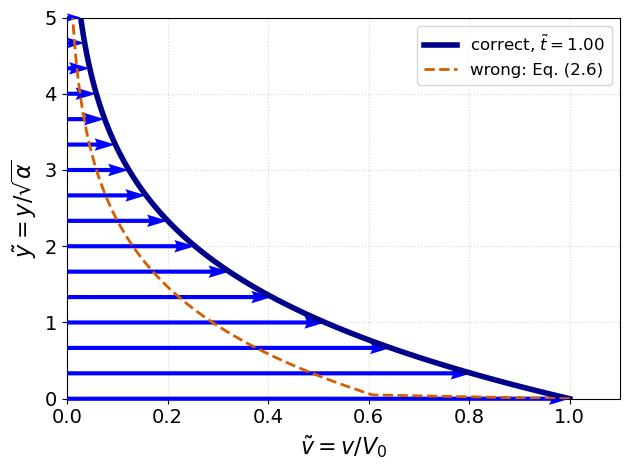

In [11]:
# Eq. (3) of I. C. Christov & C. I. Christov (2010) and Eq. (2.6) of Fetecau & Zierep (2001): static plot (the interactive widget below is stripped in the GitHub preview)
plot_func(1.0)

In [12]:
# Eq. (3) of I. C. Christov & C. I. Christov (2010) and Eq. (2.6) of Fetecau & Zierep (2001): interactive plot
interact(plot_func, t=widgets.FloatSlider(value=1.0, min=0.02, max=20, step=0.02, description='Time, t~'));

In [13]:
# Eq. (3) of I. C. Christov & C. I. Christov (2010) and Eq. (2.6) of Fetecau & Zierep (2001): animation
nu, alpha = 1.0, 1.0   # the scaled variables y~ = y/sqrt(alpha), t~ = nu t/alpha
y = np.linspace(0, 5, 101)   # fine grid for the envelope
y_arrows = np.linspace(0, 5, 16)   # about 15 arrows, one at the wall
u = profile(unsteadyv, y, 0.05, nu, alpha)

fig, ax = plt.subplots(tight_layout=True)
ax.set_ylabel(r'$\tilde y = y/\sqrt{\alpha}$')
ax.set_ylim(0, 5)
ax.set_xlabel(r'$\tilde v = v/V_0$')
ax.set_xlim(0, 1.1)
ax.grid(alpha=0.5, linestyle='dotted')
plt.close()

line, = ax.plot(u, y, color='darkblue', linewidth=4, zorder=4, label='correct')
line_wrong, = ax.plot(profile(wrong_fetecau_zierep_26, y, 0.05, nu, alpha), y, color='#D55E00',
                      linewidth=2, linestyle='dashed', zorder=4, label='wrong: Eq. (2.6)')
quiv = ax.quiver(0*y_arrows, y_arrows, np.interp(y_arrows, y, u), 0*y_arrows, scale=1., scale_units='xy', color='blue', zorder=3, clip_on=False)
ax.legend(loc='upper right')

# number of animation frames
numframes = 40
tmax = 10.0

# animation function called sequentially by `FuncAnimation' below
def animate(i):
    # the i passed is the frame counter, rescaled to get the time
    tstar = (i + 1)/numframes*tmax
    u = profile(unsteadyv, y, tstar, nu, alpha)
    line.set_data(u, y)
    line_wrong.set_data(profile(wrong_fetecau_zierep_26, y, tstar, nu, alpha), y)
    quiv.set_UVC(np.interp(y_arrows, y, u), 0*y_arrows)
    line.set_label(rf'correct, $\tilde t={tstar:.2f}$')
    legend = ax.legend(loc='upper right')
    return (line, line_wrong, quiv, legend)

anim = animation.FuncAnimation(fig, animate, frames=numframes, interval=150, blit=True, repeat=False)

In [14]:
# this is necessary to get the animation to work on Google's Colab
rc('animation', html='jshtml')
anim

In [15]:
# To save the animation, use something like
# anim.save('christov_christov_2010_startup.mp4')

# WHAT PROBLEM DOES THE WRONG SOLUTION ACTUALLY SOLVE?

As stated at the end of I. C. Christov & C. I. Christov (2010), Eq. (2.6) of Fetec&#259;u & Zierep (2001) solves two other problems:

1. the IBVP (1) with the plate started as in the theory of seepage in fissured rocks, Eq. (5.9) of [Barenblatt _et al._ (1960)](https://doi.org/10.1016/0021-8928%2860%2990107-6),
$$
    v(0,t) = \left(1 - \mathrm{e}^{-\nu t /\alpha}\right)V_0\theta(t),
$$
since its transform is Eq. (2) times $\nu/(\nu + \alpha s)$;
2. the IBVP (1) with the contrived source $2V_0\alpha\delta(t)\delta^\prime(y)$ added to the left-hand side of the equation of motion, whose Fourier sine transform, $\int_0^\infty \delta^\prime(y)\sin(\xi y)\,\mathrm{d}y = -\xi/2$ (the delta sits at the end of the half-line), cancels the term $\alpha\xi V_0$ that $V^\prime(t) = V_0\delta(t)$ contributes.

The next cell proves both in the Fourier&ndash;Laplace domain; it should print $\nu/(\alpha s + \nu)$ and $0$.

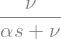

In [16]:
# The two problems solved by Eq. (2.6) of Fetecau & Zierep (2001), in the Fourier-Laplace domain
# t, nu, alpha were reused as numbers above, so declare the symbols again
t = sp.Symbol('t', real=True)
nu, alpha = sp.symbols('nu alpha', positive=True)
y_sym = sp.Symbol('y', real=True)
fourier_delta_prime = sp.integrate(sp.DiracDelta(y_sym, 1)*sp.sin(xi*y_sym), (y_sym, 0, sp.oo))   # -xi/2
source = 2*V0*alpha*sp.DiracDelta(t)*fourier_delta_prime
W_source = sp.solve(laplace(viscous_correct + source - w(t).diff(t)).subs(w0, 0), W)[0]
display(sp.simplify(W_wrong/W_correct))
display(sp.simplify(W_source - W_wrong))

Numerically, the next cell drives the scheme of Eq. (4) with the ramped plate. For the contrived source, note that Eq. (2.6) vanishes at $t = 0^+$ for $y > 0$: the source removes the start-up jump. In the scheme this is the same as starting the plate at $V_0$ already at $n = 0$ ($\mathfrak{v}_0^0 = V_0$ instead of $0$ in Eq. (5)), so that the mixed term sees no jump. Both differences from Eq. (2.6) should decrease like the scheme's error.

In [17]:
# Eq. (2.6) of Fetecau & Zierep (2001) versus the scheme of Eq. (4) for the two other problems
nu, alpha, t = 0.1, 0.1, 0.5
y = np.linspace(0.02, 1.5, 25)
u_wrong = profile(wrong_fetecau_zierep_26, y, t, nu, alpha)
y_fd, v_ramp = sg_fd(nu, alpha, t, ramp_time=alpha/nu)
y_fd, v_no_jump = sg_fd(nu, alpha, t, v00=1.0)
print(f'max|Eq. (2.6) - ramped plate, scheme| = {np.abs(u_wrong - np.interp(y, y_fd, v_ramp)).max():.1e}')
print(f'max|Eq. (2.6) - plate at V0 from n = 0, scheme| = {np.abs(u_wrong - np.interp(y, y_fd, v_no_jump)).max():.1e}')

max|Eq. (2.6) - ramped plate, scheme| = 5.1e-06
max|Eq. (2.6) - plate at V0 from n = 0, scheme| = 5.1e-06


# ON YOUR OWN

On your own:

*   Use the variables of Eq. (6) to show that the two panels of Fig. 1 are the same function of $y/\sqrt{\alpha}$ at two values of $\nu t/\alpha$.
*   Show that Eq. (2.6) of Fetec&#259;u & Zierep (2001) gives $v(y,0^+) = 0$ for every $y > 0$, and explain why no correct solution of IBVP (1) with $\alpha > 0$ can.
*   Repeat the ramped-plate check with Puri's Eq. (7) convolved with $\frac{\mathrm{d}}{\mathrm{d}t}\left(1 - \mathrm{e}^{-\nu t/\alpha}\right)$ ([Duhamel's principle](https://en.wikipedia.org/wiki/Duhamel%27s_principle)).

# REFERENCES

G. I. Barenblatt, Iu. P. Zheltov, I. N. Kochina, Basic concepts in the theory of seepage of homogeneous liquids in fissured rocks [strata], _J. Appl. Math. Mech._ **24** (1960) 1286&ndash;1303. [doi:10.1016/0021-8928(60)90107-6](https://doi.org/10.1016/0021-8928%2860%2990107-6)

I. C. Christov, C. I. Christov, Comment on &ldquo;On a class of exact solutions of the equations of motion of a second grade fluid&rdquo; by C. Fetec&#259;u and J. Zierep (Acta Mech. 150, 135&ndash;138, 2001), _Acta Mech._ **215** (2010) 25&ndash;28. [doi:10.1007/s00707-010-0300-2](https://doi.org/10.1007/s00707-010-0300-2); [arXiv:1003.2188](https://arxiv.org/abs/1003.2188)

F. R. de Hoog, J. H. Knight, A. N. Stokes, An improved method for numerical inversion of Laplace transforms, _SIAM J. Sci. Stat. Comput._ **3** (1982) 357&ndash;366. [doi:10.1137/0903022](https://doi.org/10.1137/0903022)

C. R. Harris, K. J. Millman, S. J. van der Walt, _et al._, Array programming with NumPy, _Nature_ **585** (2020) 357&ndash;362. [doi:10.1038/s41586-020-2649-2](https://doi.org/10.1038/s41586-020-2649-2)

J. D. Hunter, Matplotlib: A 2D graphics environment, _Comput. Sci. Eng._ **9** (2007) 90&ndash;95. [doi:10.1109/MCSE.2007.55](https://doi.org/10.1109/MCSE.2007.55)

A. Meurer, C. P. Smith, M. Paprocki, _et al._, SymPy: symbolic computing in Python, _PeerJ Comput. Sci._ **3** (2017) e103. [doi:10.7717/peerj-cs.103](https://doi.org/10.7717/peerj-cs.103)

The mpmath development team, _mpmath: a Python library for arbitrary-precision floating-point arithmetic_ (version 1.3.0), 2023. [mpmath.org](https://mpmath.org/)

P. Puri, Impulsive motion of a flat plate in a Rivlin&ndash;Ericksen fluid, _Rheol. Acta_ **23** (1984) 451&ndash;453. [doi:10.1007/BF01329198](https://doi.org/10.1007/BF01329198)

P. Virtanen, R. Gommers, T. E. Oliphant, _et al._, SciPy 1.0: fundamental algorithms for scientific computing in Python, _Nat. Methods_ **17** (2020) 261&ndash;272. [doi:10.1038/s41592-019-0686-2](https://doi.org/10.1038/s41592-019-0686-2)